# RQ2, Part 4: Real Exploratory Data Analysis

Real EDA tailored to RQ2's actual variables -- resolution time, priority,
era, and reassignment count. Different from RQ1's EDA entirely, since RQ2
works with issue-level process data, not code metrics.

**Requires `apache_jira_raw.csv` (Part 1) and `num_reassignments_real.csv`
(Part 2)** to already be present in this session.


In [1]:
!pip install -q pandas numpy matplotlib || pip install -q pandas numpy matplotlib --break-system-packages

1. REAL SUMMARY: N=30996 full sample, N=3000 with real reassignment data
       resolution_time_days  num_comments
count              30996.00      30996.00
mean                  70.76          6.57
std                  259.90         10.98
min                    0.00          0.00
25%                    0.41          1.00
50%                    3.54          3.00
75%                   24.16          8.00
max                 4646.11        247.00


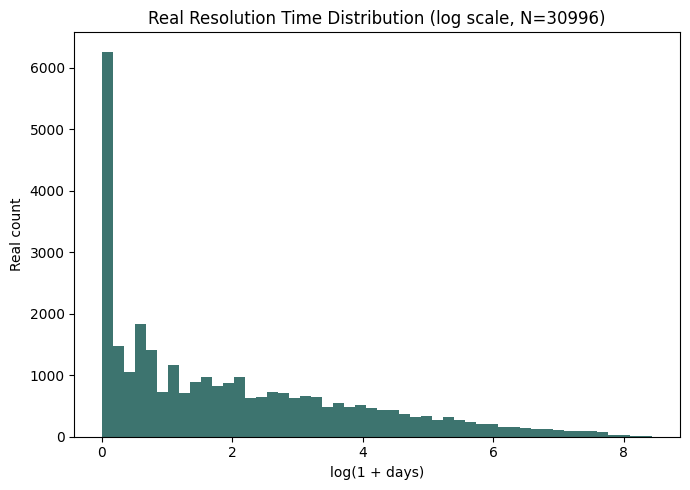

Saved rq2_eda_resolution_time_dist.png
Real median: 3.5 days, real mean: 70.8 days (the gap is why this is heavy-tailed, not normally distributed)


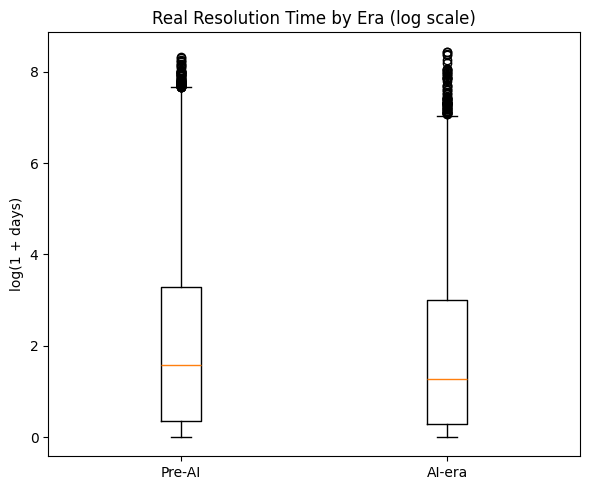

Saved rq2_eda_resolution_by_era.png
  pre_ai: real median=3.8, real mean=70.1, N=25327
  ai_era: real median=2.6, real mean=73.6, N=5669


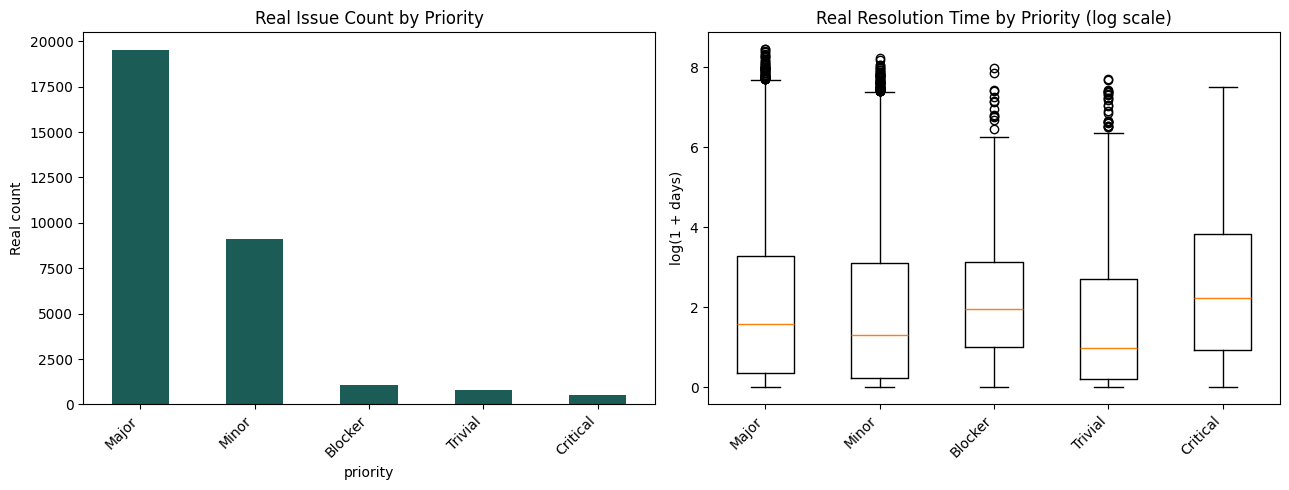

Saved rq2_eda_priority.png


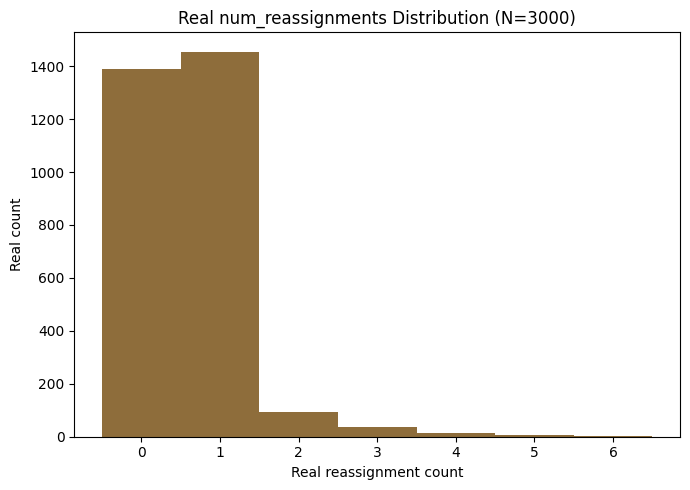

Saved rq2_eda_reassignments_dist.png
Real mean: 0.61, real median: 1, zero reassignments: 46.3%


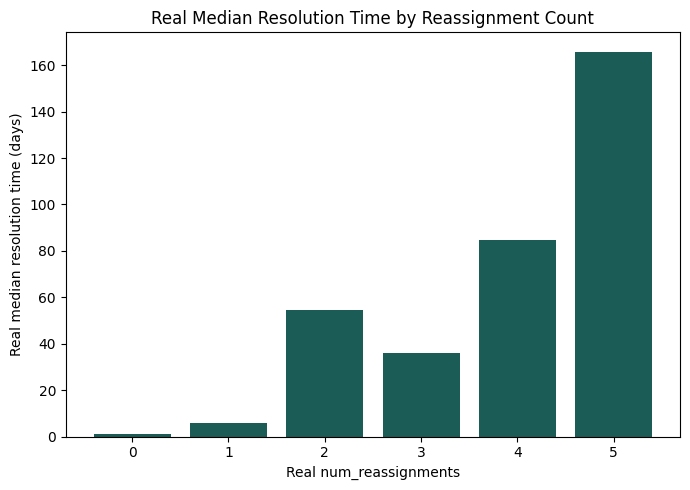

Saved rq2_eda_reassignments_vs_time.png
Real medians by reassignment count:
num_reassignments
0.0      1.2
1.0      6.0
2.0     54.4
3.0     35.9
4.0     84.9
5.0    165.9
Name: resolution_time_days, dtype: float64


In [3]:
"""
RQ2 - PART 4: Real Exploratory Data Analysis
================================================================================
Real EDA tailored to RQ2's actual variables: resolution time, priority,
comment volume, era, and reassignment count -- different from RQ1's code
metrics entirely. Covers distributions, era comparisons, priority
breakdown, and the real relationship between reassignments and resolution
time.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

jira = pd.read_csv("apache_jira_raw.csv")
jira["resolution_date_parsed"] = pd.to_datetime(jira["resolution_date"], errors="coerce", utc=True)
jira["created_parsed"] = pd.to_datetime(jira["created"], errors="coerce", utc=True)
jira["era"] = (jira["resolution_date_parsed"] >= "2023-01-01").map({True: "ai_era", False: "pre_ai"})
jira["resolution_time_days"] = (jira["resolution_date_parsed"] - jira["created_parsed"]).dt.total_seconds() / 86400
jira = jira.dropna(subset=["resolution_time_days", "priority"])
jira = jira[jira["resolution_time_days"] >= 0]

reassign = pd.read_csv("num_reassignments_real.csv")
merged = jira.merge(reassign, on="issue_id", how="inner")

print("="*70)
print(f"1. REAL SUMMARY: N={len(jira)} full sample, N={len(merged)} with real reassignment data")
print("="*70)
print(jira[["resolution_time_days", "num_comments"]].describe().round(2))

# 1. Resolution time distribution (real, heavily skewed -- log scale)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(np.log1p(jira["resolution_time_days"]), bins=50, color="#1B5C56", alpha=0.85)
ax.set_title(f"Real Resolution Time Distribution (log scale, N={len(jira)})")
ax.set_xlabel("log(1 + days)")
ax.set_ylabel("Real count")
plt.tight_layout()
plt.savefig("rq2_eda_resolution_time_dist.png", dpi=150)
plt.show()
print("Saved rq2_eda_resolution_time_dist.png")
print(f"Real median: {jira['resolution_time_days'].median():.1f} days, "
      f"real mean: {jira['resolution_time_days'].mean():.1f} days "
      f"(the gap is why this is heavy-tailed, not normally distributed)")

# 2. Resolution time by era (real boxplot)
fig, ax = plt.subplots(figsize=(6, 5))
data_by_era = [np.log1p(jira[jira.era == e]["resolution_time_days"]) for e in ["pre_ai", "ai_era"]]
ax.boxplot(data_by_era, tick_labels=["Pre-AI", "AI-era"])
ax.set_title("Real Resolution Time by Era (log scale)")
ax.set_ylabel("log(1 + days)")
plt.tight_layout()
plt.savefig("rq2_eda_resolution_by_era.png", dpi=150)
plt.show()
print("Saved rq2_eda_resolution_by_era.png")
for era in ["pre_ai", "ai_era"]:
    cell = jira[jira.era == era]["resolution_time_days"]
    print(f"  {era}: real median={cell.median():.1f}, real mean={cell.mean():.1f}, N={len(cell)}")

# 3. Priority distribution and resolution time by priority
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
jira["priority"].value_counts().plot(kind="bar", ax=axes[0], color="#1B5C56")
axes[0].set_title("Real Issue Count by Priority")
axes[0].set_ylabel("Real count")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

priorities = jira["priority"].value_counts().index.tolist()
data_by_priority = [np.log1p(jira[jira.priority == p]["resolution_time_days"]) for p in priorities]
axes[1].boxplot(data_by_priority, tick_labels=priorities)
axes[1].set_title("Real Resolution Time by Priority (log scale)")
axes[1].set_ylabel("log(1 + days)")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig("rq2_eda_priority.png", dpi=150)
plt.show()
print("Saved rq2_eda_priority.png")

# 4. num_reassignments distribution (real, from the 3,000-issue sample)
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(reassign["num_reassignments"], bins=range(0, 8), color="#7A5419", alpha=0.85, align="left")
ax.set_title(f"Real num_reassignments Distribution (N={len(reassign)})")
ax.set_xlabel("Real reassignment count")
ax.set_ylabel("Real count")
plt.tight_layout()
plt.savefig("rq2_eda_reassignments_dist.png", dpi=150)
plt.show()
print("Saved rq2_eda_reassignments_dist.png")
print(f"Real mean: {reassign['num_reassignments'].mean():.2f}, "
      f"real median: {reassign['num_reassignments'].median():.0f}, "
      f"zero reassignments: {(reassign['num_reassignments']==0).mean()*100:.1f}%")

# 5. The real relationship: reassignments vs resolution time
fig, ax = plt.subplots(figsize=(7, 5))
grouped = merged.groupby("num_reassignments")["resolution_time_days"].median()
grouped = grouped[grouped.index <= 5]  # real, meaningful range (sparse beyond this)
ax.bar(grouped.index, grouped.values, color="#1B5C56")
ax.set_title("Real Median Resolution Time by Reassignment Count")
ax.set_xlabel("Real num_reassignments")
ax.set_ylabel("Real median resolution time (days)")
plt.tight_layout()
plt.savefig("rq2_eda_reassignments_vs_time.png", dpi=150)
plt.show()
print("Saved rq2_eda_reassignments_vs_time.png")
print("Real medians by reassignment count:")
print(grouped.round(1))
